In [ ]:
pip install langdetect

In [ ]:
pip install langid


     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB 330.3 kB/s eta 0:00:06
      --------------------------------------- 0.0/1.9 MB 325.1 kB/s eta 0:00:06
     - -------------------------------------- 0.1/1.9 MB 563.7 kB/s eta 0:00:04
     -- ------------------------------------- 0.1/1.9 MB 853.3 kB/s eta 0:00:03
     ---- ----------------------------------- 0.2/1.9 MB 1.2 MB/s eta 0:00:02
     --------- ------------------------------ 0.5/1.9 MB 2.2 MB/s eta 0:00:01
     ----------------- ---------------------- 0.8/1.9 MB 3.1 MB/s eta 0:00:01
     ------------------------- -------------- 1.2/1.9 MB 4.1 MB/s eta 0:00:01
     ---------------------------------------  1.9/1.9 MB 5.5 MB/s eta 0:00:01
     ---------------------------------------- 1.9/1.9 MB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for langid: filename=l

In [ ]:
pip install googletrans==4.0.0-rc1

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
from langdetect import detect, DetectorFactory, LangDetectException
from googletrans import Translator
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv(r"C:\Users\krask\Downloads\user_reviews_data.csv")
df.head()

,Name,Rating,Description,When,place_id
0,Andreas Pantelis Moursellas,5,Εντυπωσιακό μουσείο με εκθέματα από το διαστημ...,NaN,1
1,Krasen Hristov,5,Very rich and beautiful exhibition of the USSR...,2025-9-20,1
2,Antonius,5,Павильон был построен в 1938—1939 годах и носи...,2024-11-23,1
3,Bulushova Lidiya,4,"Как музей весьма средне, а как место, где можн...",2025-3-10,1
4,Максим,5,Абсолютно стоит потраченных денег. Очень много...,2025-4-10,1


Удаление пропусков в Description;

In [16]:
df['Description'].isna().sum()

93221

In [20]:
df = df.dropna(subset=['Description'])
df['Description'].isna().sum()

0

In [21]:
df.shape

(300635, 5)

Необходимо привести все 'Description' к одному языку. Определим, какие языки встречаются в отзывах.

In [74]:
import langid

def lang_tag(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'unknown'
    lang, conf = langid.classify(text)
    return lang


In [ ]:
df_l = df.copy()

In [5]:
df_l = pd.read_csv(r'C:\Users\krask\Project_places_to_visit\df_with_lang.csv')

In [7]:
df_l.head()

,Name,Rating,Description,When,place_id,lang_tag
0,Andreas Pantelis Moursellas,5,Εντυπωσιακό μουσείο με εκθέματα από το διαστημ...,NaN,1,el
1,Krasen Hristov,5,Very rich and beautiful exhibition of the USSR...,2025-9-20,1,en
2,Antonius,5,Павильон был построен в 1938—1939 годах и носи...,2024-11-23,1,ru
3,Bulushova Lidiya,4,"Как музей весьма средне, а как место, где можн...",2025-3-10,1,ru
4,Максим,5,Абсолютно стоит потраченных денег. Очень много...,2025-4-10,1,ru


In [6]:

df_l['lang_tag'] = df_l['Description'].apply(lang_tag)

NameError: name 'lang_tag' is not defined

In [8]:
lang_counts = df_l['lang_tag'].value_counts()
lang_counts

ru    247947
en     13146
bg      8432
sr      7474
uk      4657
       ...  
is         2
pa         1
sq         1
as         1
cy         1
Name: lang_tag, Length: 91, dtype: int64

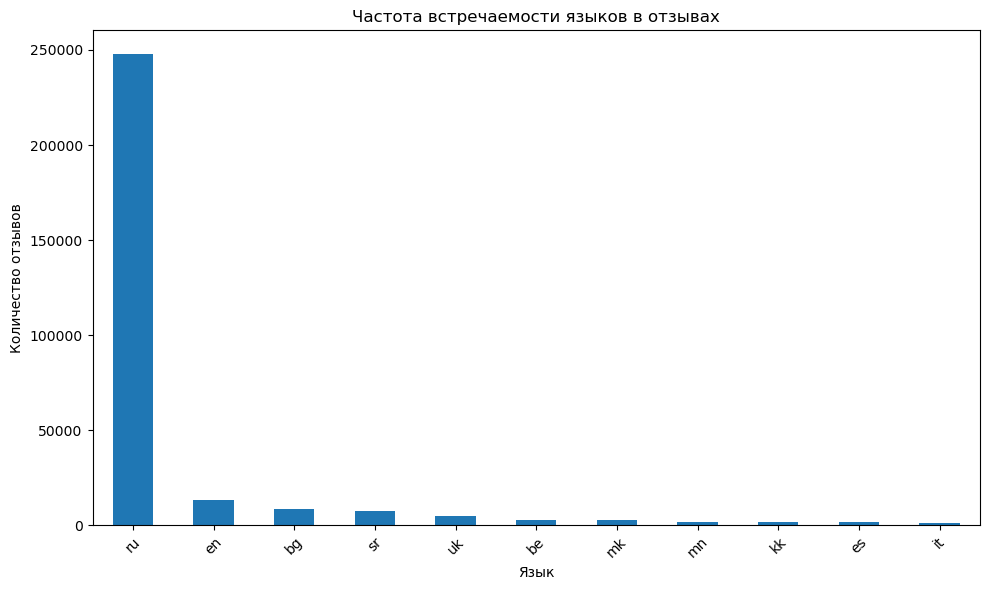

In [ ]:
plt.figure(figsize=(10,6))
lang_counts[lang_counts>=1000].plot(kind='bar')
plt.xlabel('Язык')
plt.ylabel('Количество отзывов')
plt.title('Частота встречаемости наиболее распространенных языков в отзывах')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Поскольку большинство отзывов на русском языке, необходимо перевести все иностранные отзывы именно на русский язык.

In [1]:
import pandas as pd

In [6]:
!pip install --upgrade openpyxl

   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   ------ -------------------------------- 41.0/250.9 kB 487.6 kB/s eta 0:00:01
   ------------------- -------------------- 122.9/250.9 kB 1.0 MB/s eta 0:00:01
   ---------------------------------------  245.8/250.9 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 250.9/250.9 kB 1.4 MB/s eta 0:00:00
  Attempting uninstall: openpyxl
    Found existing installation: openpyxl 3.0.10
    Uninstalling openpyxl-3.0.10:
      Successfully uninstalled openpyxl-3.0.10


In [20]:
import sys
print(sys.executable)


c:\Users\krask\anaconda3\python.exe


In [1]:
import openpyxl
print(openpyxl.__version__)


3.1.5


In [19]:
pip install --upgrade openpyxl

Note: you may need to restart the kernel to use updated packages.


In [72]:
import pandas as pd
df_tr = pd.read_excel(r'C:\Users\krask\Project_places_to_visit\translated_user_reviews_data.xltm')
df_tr.head()

,Name,Rating,Description,When,place_id,language,Перевод (Google)
0,Andreas Pantelis Moursellas,5,Εντυπωσιακό μουσείο με εκθέματα από το διαστημ...,NaT,1,el,Впечатляющий музей с экспонатами российской ко...
1,Krasen Hristov,5,Very rich and beautiful exhibition of the USSR...,2025-09-20,1,en,Очень насыщенная и красивая выставка космическ...
2,Antonius,5,Павильон был построен в 1938—1939 годах и носи...,2024-11-23,1,ru,Павильон был построен в 1938—1939 годах и носи...
3,Bulushova Lidiya,4,"Как музей весьма средне, а как место, где можн...",2025-03-10,1,ru,"Как музей весьма средне, а как место, где можн..."
4,Максим,5,Абсолютно стоит потраченных денег. Очень много...,2025-04-10,1,ru,Абсолютно стоит потраченных денег. Очень много...


Проверим, насколько корректно был совершен перевод. Есть ли не переведенные строки? 

!Стоит учитывать, что иногда для смежных языков неправильно определется язык.

In [ ]:
df_tr['check_lang'] = df_tr['Перевод (Google)'].apply(lang_tag)

In [ ]:
df_tr['check_lang'].value_counts()

check_lang
ru         267152
bg           9060
sr           7869
uk           4875
be           2969
mk           2588
mn           2072
kk           1774
ja            533
hr            476
zh            391
en            354
am             86
ky             56
vi             40
ko             39
ne             33
km             26
ml             24
hi             23
he             19
mr             15
ka             14
te             13
sl             12
de             12
fi             12
fa             11
qu             11
dz             10
si              5
cs              5
fr              5
th              4
es              3
unknown         3
kn              3
sv              3
la              3
pl              3
or              2
lb              2
lv              2
ar              2
sk              2
xh              2
rw              2
bs              2
pt              2
it              1
an              1
ro              1
bn              1
ms              1
ur              1

При обработке были замечены строки, содержащие не отзыв о месте, а призыв прекратить военную операцию. В нашем исследовании они не нужны. Необходимо найти их и удалить из датасета.

In [ ]:
import pandas as pd

def find_war_related_reviews(df, text_column='Перевод (google)'):
    keywords = ['война', 'убивать', 'украина', 'солдаты', 'войска', 'армия', 'конфликт', 'боевые', 'атака']


    pattern = '|'.join(keywords)
    mask = df[text_column].str.contains(pattern, case=False, na=False)

    filtered_df = df.loc[mask, [text_column]]

    return filtered_df.index.tolist(), filtered_df[text_column].tolist()

In [ ]:
indices, reviews = find_war_related_reviews(df_tr, text_column='Перевод (Google)')

In [ ]:
data = {
        'war_reviews': reviews
    }

filtered_df = pd.DataFrame(data, index=indices)
filtered_df

,war_reviews
277,Юнармия г.о.Реутов отряд \
5189,"Ела в этом кафе несколько раз на бизнесланче от безысходности, каждый раз надеялась, что выбрав другие блюда мне повезёт, не повезло... Качество оооочень низкое, несмотря на стандартные цены. Как ниже писали, что там один кляр везде - чистая правда, а ещё майонез абсолютно во всё наваливают. Тоже понять не могу, откуда отзывы хорошие...\n\nПоследней точкой стал жульен, он стоит 90 рублей, а там сыра вообще нет, немного грибов залитых мучномолочной смесью, хорошо, что порция мизерная, т.к. съесть более объёмную кокотницу, кажется, вообще не реально, ведь после пары ложечек попросту начинает подташнивать((( После трапезы в этом кафе некомфортное самочуствие в зоне пищеварительного тракта не редкость!\n\nНо самым грустным в этом кафе оказался совсем не жульен, а полное нежелание его начальницы принимать обратную связь от своих клиентов. Когда я ей деликатно предложила обратить внимание на качество блюд, она посчитала совершенно нормальным нахамить своему клиенту, тем самым выставив своё заведение в самом невыгодном свете. Я вела себя очень сдержанно, поэтому конфликту не удалось разгореться, хотя хозяйка кафе всячески пыталась к этому вывести путём перехода на личности, очень неприятная женщина(\n\nВ общем, не рекомендую это заведение и сама туда больше не пойду!"
7852,"4 балла за разруливание конфликтных ситуаций в пользу клиента.\nПредупредил администратора за 40 минут до посещения, что понадобится пропуск для машины. Приехали-пропуска нет. Ждали у ворот полчаса. Вместо запланированных 3х часов, съемка шла 4 часа.\nВ качестве компенсации за косяк админа предложили 2 часа бесплатно. На следующей неделе поедем снимать то, что не успели отснять."
10157,"Это один из первых общественных городских парков Москвы, раскинувшийся вдоль западной стены Кремля.\nПосле окончания войны с Наполеоном в 1812 году царь Александр I потребовал восстановления городских территорий, разрушенных французскими войсками. Сад был построен с 1819 по 1823 год и занимает площадь более 10 гектаров."
10395,"Красивая площадь с вечным огнём,где стоят солдаты,красивые статуи и столетние дубы"
10531,"Тут должен побывать каждый!\nДостоинства: Красиво, центр , история.\nНедостатки: Иногда много туристов\nГуляем постоянно по различным местам, Александровский Сад мне хорошо знаком, находится он на станции Площадь революции или Охотный ряд.\nБыли тут раз 100-200... если не больше, весной и летом там очень красиво, все цветет, тепло, можно взять мороженное, встать около перил и наслаждаться видом.\nЕще один плюс, рядом находится торговый комплекс, можно зайти в любое время, поесть, походить, купит что-то запоминающееся. Каждый, уважающий себя, житель Российской Федерации, обязательно должен посетить это место.\nРядом есть кремль, про вечный огонь я вообще молчу, не зря он так называется, можно наблюдать за этим постоянно, очень успокаивает, а стойкие солдаты верно выполняют свой долг.\nНемного пройти, есть красивый фонтан, уникальные фотографии и незабываемые впечатления ждут вас.\nЛюбители красивых фотографий не проходите мимо этого сада, задержитесь хотя бы на минут 30, вы не пожалеете об этом!"
10722,"Для меня это место связано, прежде всего, с вечным огнем. Каждый раз, бывшая на красной площади, посещаю этот сад и отдаю дань памяти павшим войнам. В целом, красивое и ухоженное место в самом центре столицы."
10856,"Это место силы и осознания, что худой мир лучше, чем любая война. Люди разных национальностей берегите друг друга, мы в первую очередь человеки и божьи создания ! В нас в каждом течёт кровь Всевышнего, дальше додумайте сами. Прогуляйтесь по Александровскому саду и присядьте на лавочку , загляните в прошлое ваших родителей, прародителей и прапрародителей , прислушайтесь к своему сердцу и разуму, сбросьте с себя зависть, злобу, ненависть в вечный огонь и радуйтесь жизни и будьте счастливы!"
10858,"Даже зимой сад красив. Здесь можно посмотреть на смену часовых у Вечного огня, которых происходит каждый час. Все п

ind_war = [13043, 35435, 53863, 68445, 68574, 73878, 73975, 86322, 102843, 110183, 110243, 110374, 110453, 111214, 134664, 141101, 142271, 145616, 149979, 173563, 200060, 298456, 298561, 298566, 298572, 298647, 298940, 298943, 299100, 299230, 299399]

In [100]:
ind_war = [13043, 35435, 53863, 68445, 68574, 73878, 73975, 86322, 102843, 110183, 110243, 110374, 110453, 111214, 134664, 141101, 142271, 145616, 149979, 173563, 200060, 298456, 298561, 298566, 298572, 298647, 298940, 298943, 299100, 299230, 299399]

In [101]:
len(ind_war)

31

In [ ]:
filtered_rows = df_tr.loc[ind_war]
filtered_rows

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
13043,Adrian Jordan (spidi2pl),1,Russian soldiers in Ukraine are killing civilians,NaT,59,en,Российские солдаты на Украине убивают мирных жителей,ru
35435,Aurin Kie,1,"Your army is killing civilians and above all else children in Ukrain. Your lunatic president is threahtening us with a nuclear weapon.\n\nYour army is joke. Running away, leaving your weapons behind. Soldiers begging to be sent home. Gipsies are farmers are stealing your tanks! Thank you, at least we wont need to supply Ukrain with as much.\n\nWe will isolate you, we will break your economy. No more flights to London, Paris, Berlin. We Lithuanias have always known you’re lunatics but now the whole world knows. Take your chance to dine and wine because soon youll be eating potatoes.\n#SlavaUkrain #SlavaHeroes",NaT,83,en,Ваша армия убивает мирное население и прежде всего детей в Украине.,ru
53863,Stefan,1,Nicht besuchen das ist für krieg,NaT,123,de,"Не посещай, это война",ru
68445,Анатолий Новиков,5,"1-й Президент Франции Наполеон, потерпел фиаско\nНа море с Англией\nИ решил отыграться на России\nАрмия Наполеона\n640.000 человек\n23 языка наемника\nПротив 220.000 Кутузова РФ\nВойна длилась пол года\n35 дней разгробление Москвы\nСадое кольцо - сожено\nГенерал Мороз Спас Россию\nПогибшие\n500.000 чел Наполеон\n120.000 чел Россия\nТем временем\nРФ Генерал въезд на\nБелом коне в Париж\nСуд Франции Наполеон\nТюрьма ссылка на остров\nP.S. чтобы выиграть в Париже, нужно проиграть в Москве. Кто с мечем придет\nОт меча и погибнет",NaT,209,ru,"1-й Президент Франции Наполеон, потерпел фиаско\nНа море с Англией\nИ решил отыграться на России\nАрмия Наполеона\n640.000 человек\n23 языка наемника\nПротив 220.000 Кутузова РФ\nВойна длилась пол года\n35 дней разгробление Москвы\nСадое кольцо - сожено\nГенерал Мороз Спас Россию\nПогибшие\n500.000 чел Наполеон\n120.000 чел Россия\nТем временем\nРФ Генерал въезд на\nБелом коне в Париж\nСуд Франции Наполеон\nТюрьма ссылка на остров\nP.S. чтобы выиграть в Париже, нужно проиграть в Москве. Кто с мечем придет\nОт меча и погибнет",ru
68574,Вадим Викторович,5,"Скажи-ка,дядя,ведь не даром Москва, спалённая пожаром, французу отдана? Ведь были ж схватки боевые, Да, говорят, ещё какие! Недаром помнит вся Россия про день Бородина! ....",NaT,209,ru,"Скажи-ка,дядя,ведь не даром Москва, спалённая пожаром, французу отдана? Ведь были ж схватки боевые, Да, говорят, ещё какие! Недаром помнит вся Россия про день Бородина! ....",ru
73878,Ula Witek,1,Russian soldiers attacked a family of 5 - parents and a 6 year old daughter were shot. Two children age 2 and 4 are badly injured.,2022-03-04,223,en,Российские солдаты напали на семью из пяти человек - родители и шестилетняя дочь были застрелены.,ru
73975,Adam Jędrzejewski,1,"Rosjanie ! Armia Rosyjska zabija dzieci i kobiety na Ukrainie !!. Zakończcie wojnę jak najszybciej. Precz z Putinem, który podpalił ten pokojowy kraj w imię swoich partykularnych interesów.",NaT,223,pl,"Русские! Российская Армия убивает детей и женщин на Украине!! Закончить войну как можно быстрее. Долой Путина, который поджег эту мирную страну во имя своих особых интересов.",ru
86322,Никита Пугач,3,"В Украине гибнут сотни мирных граждан. Российская армия стреляет по садикам и детским больницам.\nОткройте свои глаза, выключите зомбоящик!",NaT,275,ru,"В Украине гибнут сотни мирных граждан. Российская армия стреляет по садикам и детским больницам.\nОткройте свои глаза, выключите зомбоящик!",ru
102843,Jaroslav Tomáš,4,"Россия, проснись! В Украине идет война - уже погибло 5000 русских солдат! Путин начал войну, а вас у него украли!",NaT,319,ru,"Россия, проснись! В Украине идет война - уже погибло 5000 русских солдат! Путин начал войну, а вас у него украли!",ru
110183,Alan Cashman,3,"Путин вам врет. США и НАТО никому не угрожали. вам промывает мозги государственная пропаганда. они кормят вас ложью. убивают невинных мужчин, женщин и детей. Украина и мир хотят мира. Пут

In [ ]:
df_tr = df_tr.drop(index=ind_war)

In [24]:
df_tr.shape

(300604, 8)

In [26]:
df_tr.to_csv('new_user_reviews')

In [166]:
import pandas as pd
df_tr = pd.read_csv(r'C:\Users\krask\Project_places_to_visit\new_user_reviews')
df_tr = df_tr.loc[:, ~df_tr.columns.str.contains('^Unnamed')]
df_tr

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
0,Andreas Pantelis Moursellas,5,Εντυπωσιακό μουσείο με εκθέματα από το διαστημ...,NaN,1,el,Впечатляющий музей с экспонатами российской ко...,ru
1,Krasen Hristov,5,Very rich and beautiful exhibition of the USSR...,2025-09-20,1,en,Очень насыщенная и красивая выставка космическ...,ru
2,Antonius,5,Павильон был построен в 1938—1939 годах и носи...,2024-11-23,1,ru,Павильон был построен в 1938—1939 годах и носи...,ru
3,Bulushova Lidiya,4,"Как музей весьма средне, а как место, где можн...",2025-03-10,1,ru,"Как музей весьма средне, а как место, где можн...",ru
4,Максим,5,Абсолютно стоит потраченных денег. Очень много...,2025-04-10,1,ru,Абсолютно стоит потраченных денег. Очень много...,ru
...,...,...,...,...,...,...,...,...
300599,Nick “Furi? Kuri!”,5,"Отличное место! Очень радует, что в этом район...",2020-11-04,886,ru,"Отличное место! Очень радует, что в этом район...",ru
300600,Паша Латышенок,5,"Хорошо уютное заведение, очень вежливый персон...",2020-09-25,886,ru,"Хорошо уютное заведение, очень вежливый персон...",ru
300601,Екатерина «Katierra» Шевич,5,Любимое место уже не первый год.\nЗаказываю бе...,NaN,886,ru,Любимое место уже не первый год.\nЗаказываю бе...,ru
300602,Надежда Осипова,5,Праздновали день рождения) никому не говорили ...,NaN,886,ru,Праздновали день рождения) никому не говорили ...,ru


В отзывах есть текст, не содержащий буквенных символов. Проверим, являются ли эти данными полезными данными, нет ли в них ошибок и т.п. Проведем анализ.

In [77]:
def find_only_nonalpha_strings(df, column_name):
    pattern = r'^[^a-zA-Zа-яА-ЯёЁ]+$'
    return df[df[column_name].astype(str).str.match(pattern)]


In [78]:
df_nonalpha = find_only_nonalpha_strings(df_tr, 'Перевод (Google)')
df_nonalpha

,Unnamed: 0,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
2834,2834,Kamil Szostak,5,5+ !,NaN,1,unknown,5+ !,en
2904,2904,Süleyman Demirbag,5,👍,NaN,1,unknown,👍,ja
3027,3027,Илья Бронских,5,👍👍,2019-01-18,1,unknown,👍👍,hr
3060,3060,Павел Жмотов,5,"""Мир"" жалко. Такую станцию прое...",NaN,1,ru,\,en
3295,3295,Эля,5,"""Кинозал 5D""",2019-07-25,1,bg,\,en
...,...,...,...,...,...,...,...,...,...
299539,299570,Александр Волчков,5,👍👍👍,NaN,870,unknown,👍👍👍,hr
299655,299686,Igor Weber,5,✨🌟🏆🏆🏆🌟✨,NaN,871,unknown,✨🌟🏆🏆🏆🌟✨,zh
300198,300229,[PROFF] Альянс,5,"""Ценителям грузинской кухни посвящается...""©\n...",2021-04-11,883,ru,\,en
300561,300592,Анна Климкова,5,👍,NaN,883,unknown,👍,ja


При переводе некоторые строки перевелись неверно. Вместо их перевода на русский были добавлены символы $/$. Исправим это.

In [79]:
def find_only_backslash_strings(df, column_name):
    pattern = r'^[\\]+$'
    return df[df[column_name].astype(str).str.match(pattern)]

In [80]:
df_backslash_only = find_only_backslash_strings(df_tr, 'Перевод (Google)')
df_backslash_only = df_backslash_only.loc[:, ~df_backslash_only.columns.str.contains('^Unnamed')]

df_backslash_only

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
3060,Павел Жмотов,5,"""Мир"" жалко. Такую станцию прое...",NaN,1,ru,\,en
3295,Эля,5,"""Кинозал 5D""",2019-07-25,1,bg,\,en
4503,Елена Васенина,5,"""Театр начинается с вешалки""... Вот в этом слу...",NaN,10,ru,\,en
4666,Илья Илья,5,"""Записные книжки"" Не заскучаете)))",2017-10-24,10,ru,\,en
4814,JuliaShu@gmail.com Shushina,5,"""Заповедник "" - просто шедевр. Браво!",NaN,10,mk,\,en
...,...,...,...,...,...,...,...,...
294137,Мария Цицеронова,1,"""Грабли"", что с вами произошло?? Была на Алекс...",NaN,866,ru,\,en
297266,Ehab Mitwalli,5,“Had an amazing experience at Grand Café Dr. Z...,2025-02-26,870,en,\,en
297573,Semion Sidorenko,1,"""Одноразовое кафе для не слишком образованных ...",NaN,870,ru,\,en
298222,TehCrimsonArmy,5,"""Когда они назвали их рестораном grand, я не о...",2018-01-24,870,ru,\,en


Для столбцов с русским языком скопируем данные из столбца 'Description' в столбец 'Перевод (Google)'

In [81]:
df_backslash_only.loc[df_backslash_only['language']=='ru', 'Перевод (Google)'] = df_backslash_only['Description']
df_backslash_only.loc[df_backslash_only['Перевод (Google)'] == '\\']

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
3295,Эля,5,"""Кинозал 5D""",2019-07-25,1,bg,\,en
4814,JuliaShu@gmail.com Shushina,5,"""Заповедник "" - просто шедевр. Браво!",NaN,10,mk,\,en
66622,Ксения,1,"""бар переполнен""\nСидит три человека.\nКрасиво...",NaN,191,mk,\,en
76621,Mushtaq Hussain,5,"""Liga Billiards Club is an absolute gem! The a...",NaN,252,en,\,en
76736,adnan raja,5,"""5 stars aren't enough for this amazing billia...",NaN,252,en,\,en
77749,Роман Тавасиев,5,"""Пять""",NaN,254,uk,\,en
92254,iliana일리아나,5,"""SYMPHONY IN C ""It was a great performance.",NaN,289,en,\,en
110303,Jean Loup Le Corre,5,"La"" the place to be"" de la restauration des ha...",NaN,360,fr,\,en
121428,Анатолий Жульев,5,"""Пола Негри""- круто!",NaN,378,mk,\,en
151130,sofia silinik,1,“Very good”?! Are you people out of your mind?...,NaN,525,en,\,en


In [82]:
df_backslash_only.loc[(df_backslash_only['Перевод (Google)'] == '\\') & (df_backslash_only['language'].isin(['bg', 'mk'])), :]

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
3295,Эля,5,"""Кинозал 5D""",2019-07-25,1,bg,\,en
4814,JuliaShu@gmail.com Shushina,5,"""Заповедник "" - просто шедевр. Браво!",NaN,10,mk,\,en
66622,Ксения,1,"""бар переполнен""\nСидит три человека.\nКрасиво...",NaN,191,mk,\,en
121428,Анатолий Жульев,5,"""Пола Негри""- круто!",NaN,378,mk,\,en


В этих четырех строках выше на самом деле тоже представлен русский текст. Скопируем текст из столбца 'Description' в столбец 'Перевод (Google)'

In [83]:
df_backslash_only.loc[(df_backslash_only['Перевод (Google)'] == '\\') & (df_backslash_only['language'].isin(['bg', 'mk'])), 'Перевод (Google)'] =  df_backslash_only.loc[(df_backslash_only['Перевод (Google)'] == '\\') & (df_backslash_only['language'].isin(['bg', 'mk'])), 'Description']
df_backslash_only.loc[df_backslash_only['Перевод (Google)'] == '\\']

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
76621,Mushtaq Hussain,5,"""Liga Billiards Club is an absolute gem! The a...",NaN,252,en,\,en
76736,adnan raja,5,"""5 stars aren't enough for this amazing billia...",NaN,252,en,\,en
77749,Роман Тавасиев,5,"""Пять""",NaN,254,uk,\,en
92254,iliana일리아나,5,"""SYMPHONY IN C ""It was a great performance.",NaN,289,en,\,en
110303,Jean Loup Le Corre,5,"La"" the place to be"" de la restauration des ha...",NaN,360,fr,\,en
151130,sofia silinik,1,“Very good”?! Are you people out of your mind?...,NaN,525,en,\,en
246172,Hassan Aljaziri,5,"""زيارتي لمطعم جورجي كانت تجربة لذيذة وممتعة! ط...",2023-11-21,824,ar,\,en
254393,Aisha,3,“Gorky Central Park of Culture and Leisure is ...,2023-10-16,849,en,\,en
297266,Ehab Mitwalli,5,“Had an amazing experience at Grand Café Dr. Z...,2025-02-26,870,en,\,en


In [84]:
df_backslash_only.loc[(df_backslash_only['Перевод (Google)'] == '\\') & (df_backslash_only['language'] == 'uk'), :]

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
77749,Роман Тавасиев,5,"""Пять""",NaN,254,uk,\,en


Данный отзыв вообще не является информативным. Удалим его:

In [85]:
df_backslash_only.drop(77749, inplace=True)

In [167]:
df_tr.drop(77749, inplace=True)

In [86]:
df_backslash_only

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
3060,Павел Жмотов,5,"""Мир"" жалко. Такую станцию прое...",NaN,1,ru,"""Мир"" жалко. Такую станцию прое...",en
3295,Эля,5,"""Кинозал 5D""",2019-07-25,1,bg,"""Кинозал 5D""",en
4503,Елена Васенина,5,"""Театр начинается с вешалки""... Вот в этом слу...",NaN,10,ru,"""Театр начинается с вешалки""... Вот в этом слу...",en
4666,Илья Илья,5,"""Записные книжки"" Не заскучаете)))",2017-10-24,10,ru,"""Записные книжки"" Не заскучаете)))",en
4814,JuliaShu@gmail.com Shushina,5,"""Заповедник "" - просто шедевр. Браво!",NaN,10,mk,"""Заповедник "" - просто шедевр. Браво!",en
...,...,...,...,...,...,...,...,...
294137,Мария Цицеронова,1,"""Грабли"", что с вами произошло?? Была на Алекс...",NaN,866,ru,"""Грабли"", что с вами произошло?? Была на Алекс...",en
297266,Ehab Mitwalli,5,“Had an amazing experience at Grand Café Dr. Z...,2025-02-26,870,en,\,en
297573,Semion Sidorenko,1,"""Одноразовое кафе для не слишком образованных ...",NaN,870,ru,"""Одноразовое кафе для не слишком образованных ...",en
298222,TehCrimsonArmy,5,"""Когда они назвали их рестораном grand, я не о...",2018-01-24,870,ru,"""Когда они назвали их рестораном grand, я не о...",en


In [91]:
df_backslash_only.loc[df_backslash_only['Перевод (Google)']=='\\']

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
76621,Mushtaq Hussain,5,"""Liga Billiards Club is an absolute gem! The a...",NaN,252,en,\,en
76736,adnan raja,5,"""5 stars aren't enough for this amazing billia...",NaN,252,en,\,en
92254,iliana일리아나,5,"""SYMPHONY IN C ""It was a great performance.",NaN,289,en,\,en
110303,Jean Loup Le Corre,5,"La"" the place to be"" de la restauration des ha...",NaN,360,fr,\,en
151130,sofia silinik,1,“Very good”?! Are you people out of your mind?...,NaN,525,en,\,en
246172,Hassan Aljaziri,5,"""زيارتي لمطعم جورجي كانت تجربة لذيذة وممتعة! ط...",2023-11-21,824,ar,\,en
254393,Aisha,3,“Gorky Central Park of Culture and Leisure is ...,2023-10-16,849,en,\,en
297266,Ehab Mitwalli,5,“Had an amazing experience at Grand Café Dr. Z...,2025-02-26,870,en,\,en


Осталось перевести корректно эти 8 строк на русский язык и перезаписать верный перевод в столбец 'Перевод (Google)'

In [96]:
from googletrans import Translator

translator = Translator()

def translate_text(text):
    if pd.isnull(text):
        return text
    try:
        result = translator.translate(text, dest='ru')
        return result.text
    except Exception as e:
        return None 

translated= df_backslash_only.loc[df_backslash_only['Перевод (Google)']=='\\', 'Description'].apply(translate_text)

In [98]:
df_backslash_only.loc[df_backslash_only['Перевод (Google)']=='\\', 'Перевод (Google)'] = translated

In [99]:
df_backslash_only

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
3060,Павел Жмотов,5,"""Мир"" жалко. Такую станцию прое...",NaN,1,ru,"""Мир"" жалко. Такую станцию прое...",en
3295,Эля,5,"""Кинозал 5D""",2019-07-25,1,bg,"""Кинозал 5D""",en
4503,Елена Васенина,5,"""Театр начинается с вешалки""... Вот в этом слу...",NaN,10,ru,"""Театр начинается с вешалки""... Вот в этом слу...",en
4666,Илья Илья,5,"""Записные книжки"" Не заскучаете)))",2017-10-24,10,ru,"""Записные книжки"" Не заскучаете)))",en
4814,JuliaShu@gmail.com Shushina,5,"""Заповедник "" - просто шедевр. Браво!",NaN,10,mk,"""Заповедник "" - просто шедевр. Браво!",en
...,...,...,...,...,...,...,...,...
294137,Мария Цицеронова,1,"""Грабли"", что с вами произошло?? Была на Алекс...",NaN,866,ru,"""Грабли"", что с вами произошло?? Была на Алекс...",en
297266,Ehab Mitwalli,5,“Had an amazing experience at Grand Café Dr. Z...,2025-02-26,870,en,"""Потрясающие впечатления от Гранд Кафе Доктор ...",en
297573,Semion Sidorenko,1,"""Одноразовое кафе для не слишком образованных ...",NaN,870,ru,"""Одноразовое кафе для не слишком образованных ...",en
298222,TehCrimsonArmy,5,"""Когда они назвали их рестораном grand, я не о...",2018-01-24,870,ru,"""Когда они назвали их рестораном grand, я не о...",en


Обновим значения в исходном датасете:

In [168]:
df_tr.update(df_backslash_only)

In [169]:
# Проверка
df_tr.loc[df_tr['Перевод (Google)']=='\\', :]

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang


Вернемся к отзывам, которые не содержат буквенных символов:

In [154]:
df_nonalpha = find_only_nonalpha_strings(df_tr, 'Перевод (Google)')
df_nonalpha = df_nonalpha.loc[:, ~df_nonalpha.columns.str.contains('^Unnamed')]
df_nonalpha

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
2834,Kamil Szostak,5,5+ !,NaN,1,unknown,5+ !,en
2904,Süleyman Demirbag,5,👍,NaN,1,unknown,👍,ja
3027,Илья Бронских,5,👍👍,2019-01-18,1,unknown,👍👍,hr
3402,Ильдар Газеев,5,👍🤗😁,NaN,1,unknown,👍🤗😁,hi
3457,ralf ralf,5,🔥👍,NaN,1,unknown,🔥👍,ja
...,...,...,...,...,...,...,...,...
299538,Susana García,5,👍,NaN,870,unknown,👍,ja
299539,Александр Волчков,5,👍👍👍,NaN,870,unknown,👍👍👍,hr
299655,Igor Weber,5,✨🌟🏆🏆🏆🌟✨,NaN,871,unknown,✨🌟🏆🏆🏆🌟✨,zh
300561,Анна Климкова,5,👍,NaN,883,unknown,👍,ja


In [155]:
df_nonalpha.loc[:, 'Description'].value_counts()

Description
👍                         310
👍👍👍                       239
👍👍👍👍👍                      62
👍👍👍👍                       49
👍👍                         34
                         ... 
👍👍👍❤️❤️❤️                   1
✌️👍                         1
👍🏼👍🏼👍🏼👍🏼👍🏼                  1
😘🤗😀                         1
👍👍👍👍👍👍👍👍👍👍👍💖💖💖💖💖💖💖💖💖💖💖      1
Name: count, Length: 507, dtype: int64

В основном там содержатся эмодзи. Их анализ не будет проводится, поскольку по ним практически невозможно детально достоверно определить эмоции или тональность отзыва.

Один и тот же эмодзи может отображать разные настроения.

Например, 👍 может быть поставлен как оценка "нормально", а может быть - как "отлично". Эту разницу невозможно уловить без дополнительного текстового содержания, а оно в этих отзывах отсутствует. Поэтому такие отзывы тоже удалим из датасета.

In [170]:
df_tr = df_tr.drop(df_nonalpha.index).reset_index(drop=True)

In [172]:
df_tr.shape

(299028, 8)

In [173]:
df_tr.to_csv('last_user_reviews')

In [1]:
import pandas as pd

# Читаем файл без расширения
df = pd.read_csv('last_user_reviews')

# Сохраняем правильно с расширением .csv
df.to_csv('last_user_reviews.csv', index=False)

# (Опционально) Удаляем старый файл без расширения
import os
os.remove('last_user_reviews')

In [3]:
df = pd.read_csv('last_user_reviews.csv')
df = df.drop(columns=['Unnamed: 0'])

# Теперь сохраняем правильно
df.to_csv('last_user_reviews.csv', index=False)

In [2]:
import pandas as pd

df = pd.read_csv('last_user_reviews.csv')

# Переименовываем столбец "Перевод (Google)" в "text"
df = df.rename(columns={'Перевод (Google)': 'text'})

# Группируем по place_id и сохраняем отдельные файлы
for place_id, group in df.groupby('place_id'):
    # Выбираем только нужный столбец (теперь он называется 'text')
    output_df = group[['text']].copy()
    
    # Сохраняем в файл (имя файла = place_id)
    output_df.to_csv(f'{place_id}.csv', index=False, encoding='utf-8-sig')
    
    # Если хотите Excel файлы:
    # output_df.to_excel(f'{place_id}.xlsx', index=False)
    
    print(f"Создан файл: {place_id}.csv ({len(output_df)} строк)")

print("Готово! Все файлы созданы.")

Создан файл: 1.csv (3935 строк)
Создан файл: 2.csv (42 строк)
Создан файл: 4.csv (107 строк)
Создан файл: 5.csv (82 строк)
Создан файл: 6.csv (92 строк)
Создан файл: 7.csv (105 строк)
Создан файл: 8.csv (54 строк)
Создан файл: 9.csv (16 строк)
Создан файл: 10.csv (485 строк)
Создан файл: 11.csv (97 строк)
Создан файл: 12.csv (127 строк)
Создан файл: 13.csv (21 строк)
Создан файл: 14.csv (83 строк)
Создан файл: 17.csv (11 строк)
Создан файл: 19.csv (107 строк)
Создан файл: 20.csv (204 строк)
Создан файл: 21.csv (2119 строк)
Создан файл: 22.csv (17 строк)
Создан файл: 23.csv (14 строк)
Создан файл: 24.csv (83 строк)
Создан файл: 26.csv (3 строк)
Создан файл: 27.csv (6 строк)
Создан файл: 29.csv (81 строк)
Создан файл: 31.csv (4 строк)
Создан файл: 32.csv (19 строк)
Создан файл: 33.csv (166 строк)
Создан файл: 35.csv (158 строк)
Создан файл: 36.csv (292 строк)
Создан файл: 37.csv (53 строк)
Создан файл: 38.csv (19 строк)
Создан файл: 39.csv (15 строк)
Создан файл: 40.csv (25 строк)
Создан

In [4]:
df

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
0,Andreas Pantelis Moursellas,5,Εντυπωσιακό μουσείο με εκθέματα από το διαστημ...,NaN,1,el,Впечатляющий музей с экспонатами российской ко...,ru
1,Krasen Hristov,5,Very rich and beautiful exhibition of the USSR...,2025-09-20,1,en,Очень насыщенная и красивая выставка космическ...,ru
2,Antonius,5,Павильон был построен в 1938—1939 годах и носи...,2024-11-23,1,ru,Павильон был построен в 1938—1939 годах и носи...,ru
3,Bulushova Lidiya,4,"Как музей весьма средне, а как место, где можн...",2025-03-10,1,ru,"Как музей весьма средне, а как место, где можн...",ru
4,Максим,5,Абсолютно стоит потраченных денег. Очень много...,2025-04-10,1,ru,Абсолютно стоит потраченных денег. Очень много...,ru
...,...,...,...,...,...,...,...,...
299023,Nick “Furi? Kuri!”,5,"Отличное место! Очень радует, что в этом район...",2020-11-04,886,ru,"Отличное место! Очень радует, что в этом район...",ru
299024,Паша Латышенок,5,"Хорошо уютное заведение, очень вежливый персон...",2020-09-25,886,ru,"Хорошо уютное заведение, очень вежливый персон...",ru
299025,Екатерина «Katierra» Шевич,5,Любимое место уже не первый год.\nЗаказываю бе...,NaN,886,ru,Любимое место уже не первый год.\nЗаказываю бе...,ru
299026,Надежда Осипова,5,Праздновали день рождения) никому не говорили ...,NaN,886,ru,Праздновали день рождения) никому не говорили ...,ru
